# Larva Behaviour Analysis

This notebook is the only file you need to touch for a standard analysis run.
All computation lives in `metrics.py`, all plotting in `figures.py`, all constants
in `config.py`, and all loading/cleaning in `io.py`.

**File layout expected in the same directory as this notebook:**
```
config.py
larva_io.py
metrics.py
figures.py
analysis.ipynb   ← this file
```

## 1  Imports

We import `io` under the alias `larva_io` to avoid shadowing Python's built-in
`io` module — if you wrote `import io` without an alias, any internal call to
Python's own `io` (e.g. for file reading) would silently break.

`%autoreload 2` tells Jupyter to re-import every module automatically before
each cell runs. This means you can edit `figures.py` or `metrics.py` and see
the changes immediately without restarting the kernel.

In [6]:
%load_ext autoreload
%autoreload 2

import larva_io
import figures
import config
import metrics

import tkinter
from tkinter import filedialog
tkinter.Tk().withdraw()   # hide the root Tk window; only the picker dialog appears

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


''

## 2  Load and preprocess data

`filedialog.askdirectory()` opens a folder-picker dialog. Choose the **root**
directory of your experiment — `io.preprocess()` will walk the whole tree
recursively and load every CSV it finds.

`larva_io.preprocess()` runs the full pipeline in one call:
1. **load** — reads all CSVs and parses metadata from folder names
2. **filter_frames** — drops rows with Frame ≥ `max_frame` (default 600)
3. **interpolate** — fills missing X/Y values within each (Trial, Condition)
4. **add_distance** — computes Euclidean distance to the odour source

Speed filtering is **not** applied here. It happens inside the individual
figure functions that need clean locomotion data, so that functions like
`stopping_frequency` (which needs the slow frames) receive the full data.

In [7]:
filepath = filedialog.askdirectory()

df = larva_io.preprocess(filepath)

# Quick sanity check: shapes and conditions loaded
print(f"Rows: {len(df):,}   Columns: {df.columns.tolist()}")
print(f"Conditions: {sorted(df['Condition'].unique())}")
print(f"Frame range: {df['Frame'].min()} – {df['Frame'].max()}")
df.head(3)

d:\Experiment Work\larva-locater Repo\larva-locater\larva_io.py:58: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


Rows: 375,117   Columns: ['Odour', 'Y', 'X', 'Speed', 'VY', 'Frame', 'Trial', 'Condition', 'Genotype', 'Starvation', 'Collective', 'Concentration', 'Individual', 'Distance']
Conditions: ['H2 WT 5h Group 10-0', 'H2 WT Fed Group 10-0', 'PA WT 5h Group 10-4', 'PA WT Fed Group 10-4']
Frame range: 0.0 – 599.0


,Odour,Y,X,Speed,VY,Frame,Trial,Condition,Genotype,Starvation,Collective,Concentration,Individual,Distance
0,H2,18.800,28.351,0.000,0.000,0.0,H2 WT 5h Group 10-0_1_1__conv,H2 WT 5h Group 10-0,WT,5h,Group,10-0,H2 WT 5h Group 10-0_1_1__conv_fish0.csv,22.095049
1,H2,18.800,28.351,0.000,0.000,1.0,H2 WT 5h Group 10-0_1_1__conv,H2 WT 5h Group 10-0,WT,5h,Group,10-0,H2 WT 5h Group 10-0_1_1__conv_fish0.csv,22.095049
2,H2,18.812,28.346,0.073,0.124,2.0,H2 WT 5h Group 10-0_1_1__conv,H2 WT 5h Group 10-0,WT,5h,Group,10-0,H2 WT 5h Group 10-0_1_1__conv_fish0.csv,22.100929


### Optional: override defaults

If this experiment uses a different frame cutoff or odour source position,
pass them explicitly here instead of editing `config.py`.
Only run this cell if you need to deviate from the defaults.

In [ ]:
# df = larva_io.preprocess(
#     filepath,
#     max_frame=900,      # override the default 600-frame cutoff
#     target_x=14,        # odour source X — only needed if different from config.TARGET_X
#     target_y=2,         # odour source Y
# )

In [ ]:
# df_PA = df[df['Odour'] == 'PA']
# df_PA = df_PA[df_PA['Genotype'] == 'WT']
# df_PA = df_PA[df_PA['Starvation'] != '17h']
# df_PA = df_PA[df_PA['Concentration'] == '10-4']

## 3  Standard pipeline (90% of runs)

### 3A  Behaviour summary over time

This is the main figure — three panels in one call:

- **Panel A** Cumulative success rate: the proportion of individuals that have
  reached the odour source by each frame bin, plotted as a line ± SEM shading.
  A steeper rise = faster navigation.

- **Panel B** Preference index over time: PI = (time in bottom zone − time in
  top zone) / (bottom + top). Positive = bias toward the odour end.
  Plotted per 100-frame bin with SEM error bars.

- **Panel C** Post-success dwell time: for individuals that reached the target,
  how many frames did they spend inside after first entry.
  Failed individuals are excluded from this panel only.

The function returns the three underlying DataFrames in case you want to do
statistics on them directly.

In [14]:
df_singular = df[df['Condition'] == 'H2 WT Fed Group 10-0']

ZeroDivisionError: float division by zero

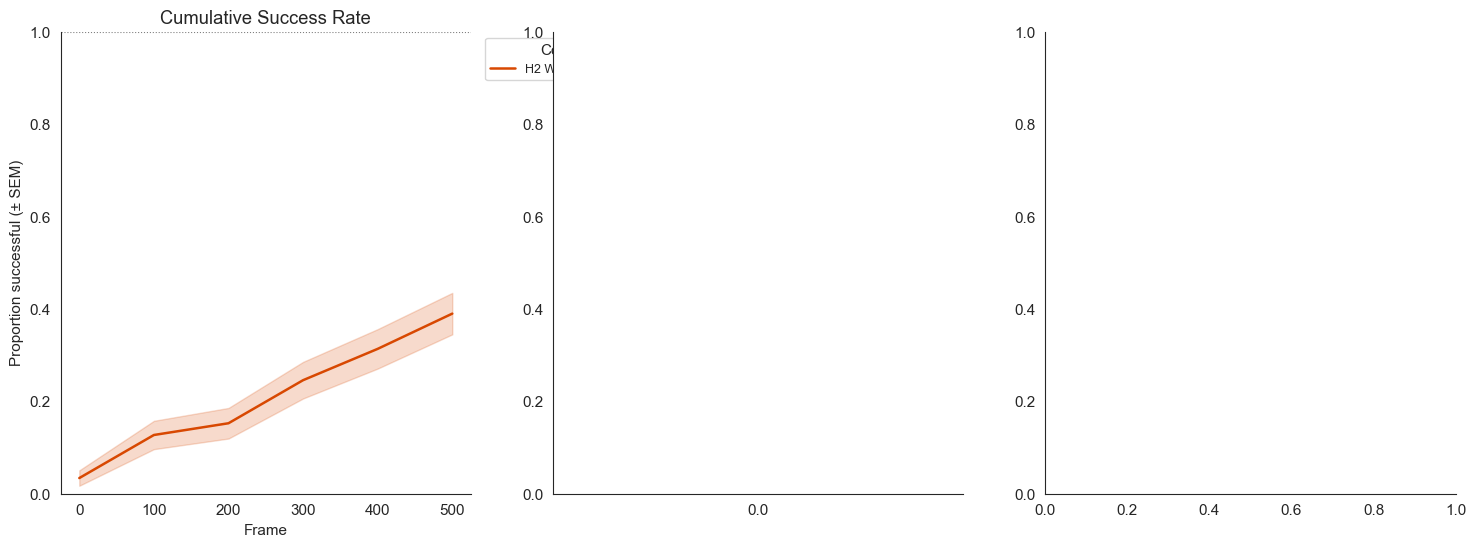

In [15]:
cumul_df, pref_df, dwell_df = figures.behavior_summary_overtime(df_singular)

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1012: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1020: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


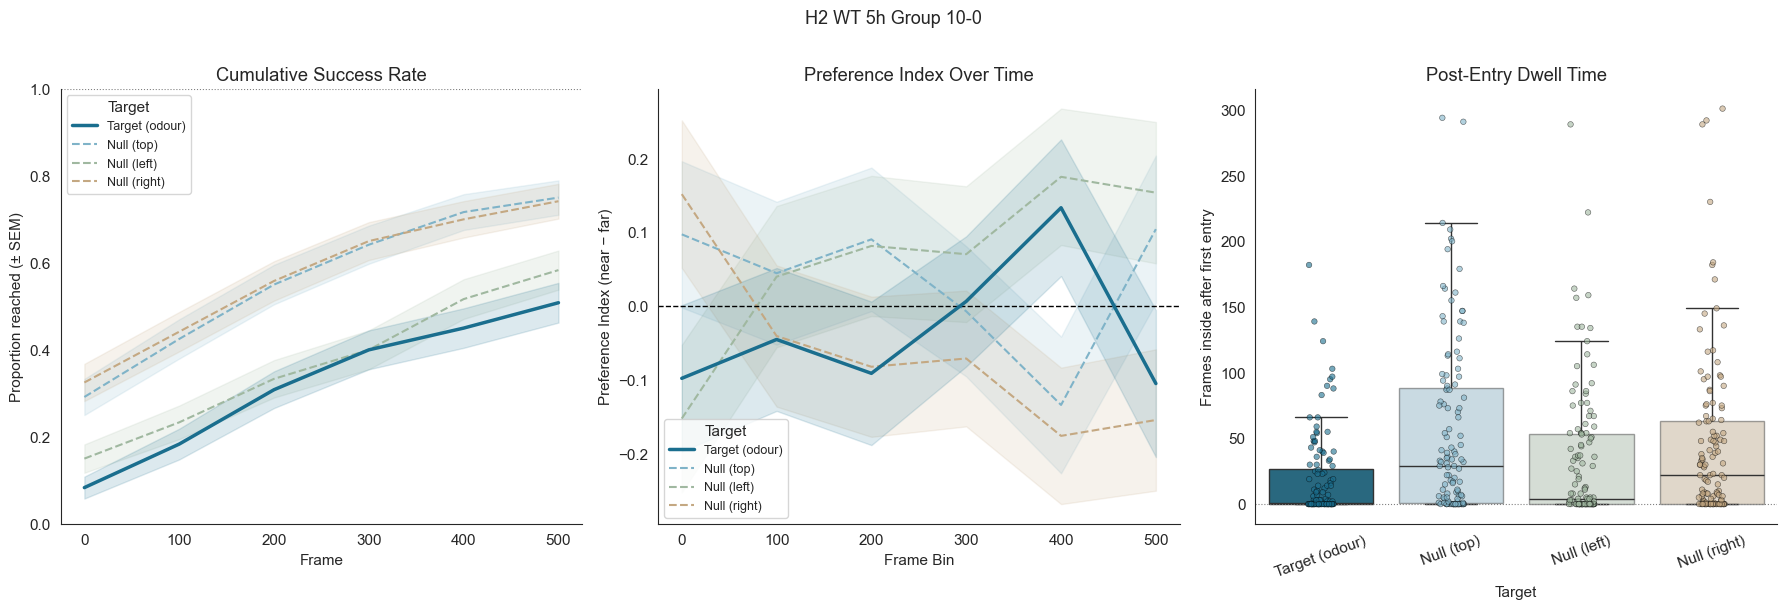

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1012: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1020: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


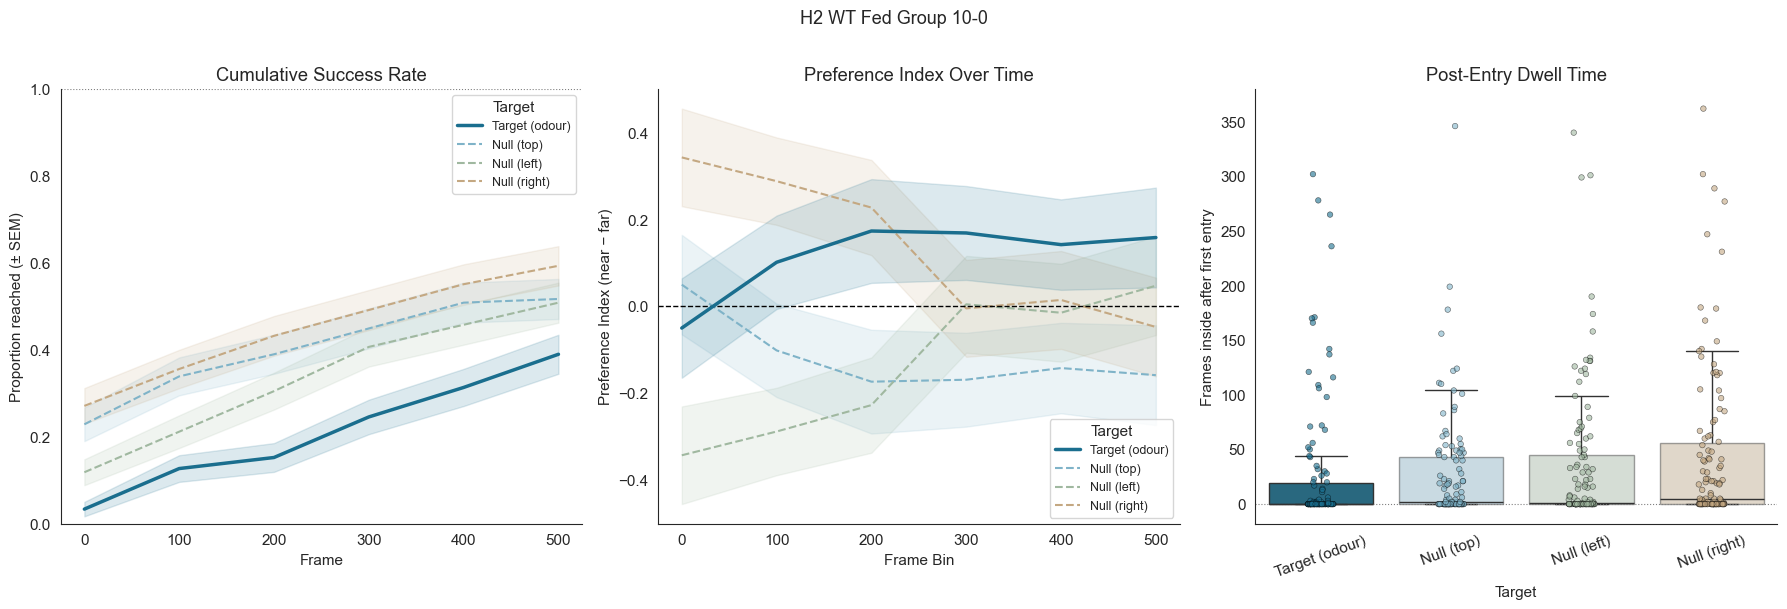

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1012: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1020: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


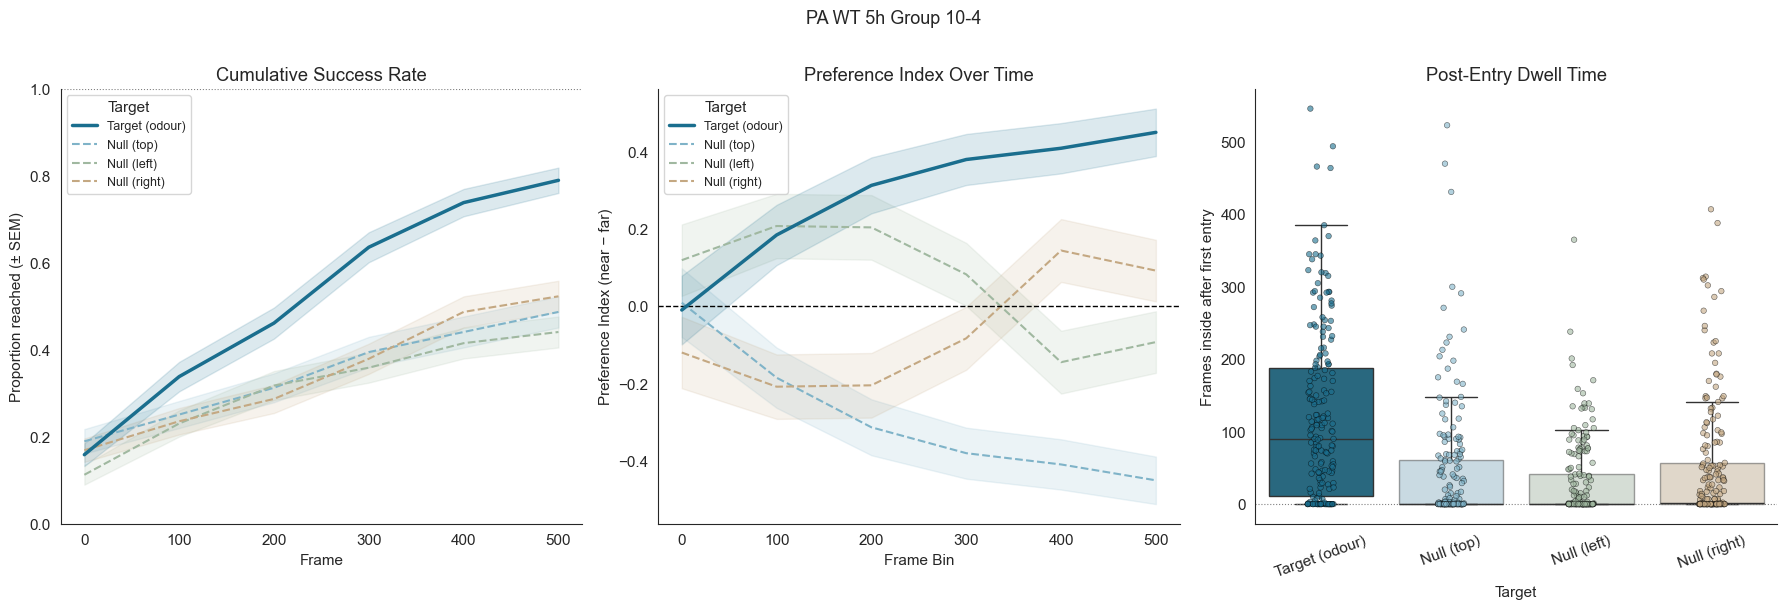

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1012: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1020: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


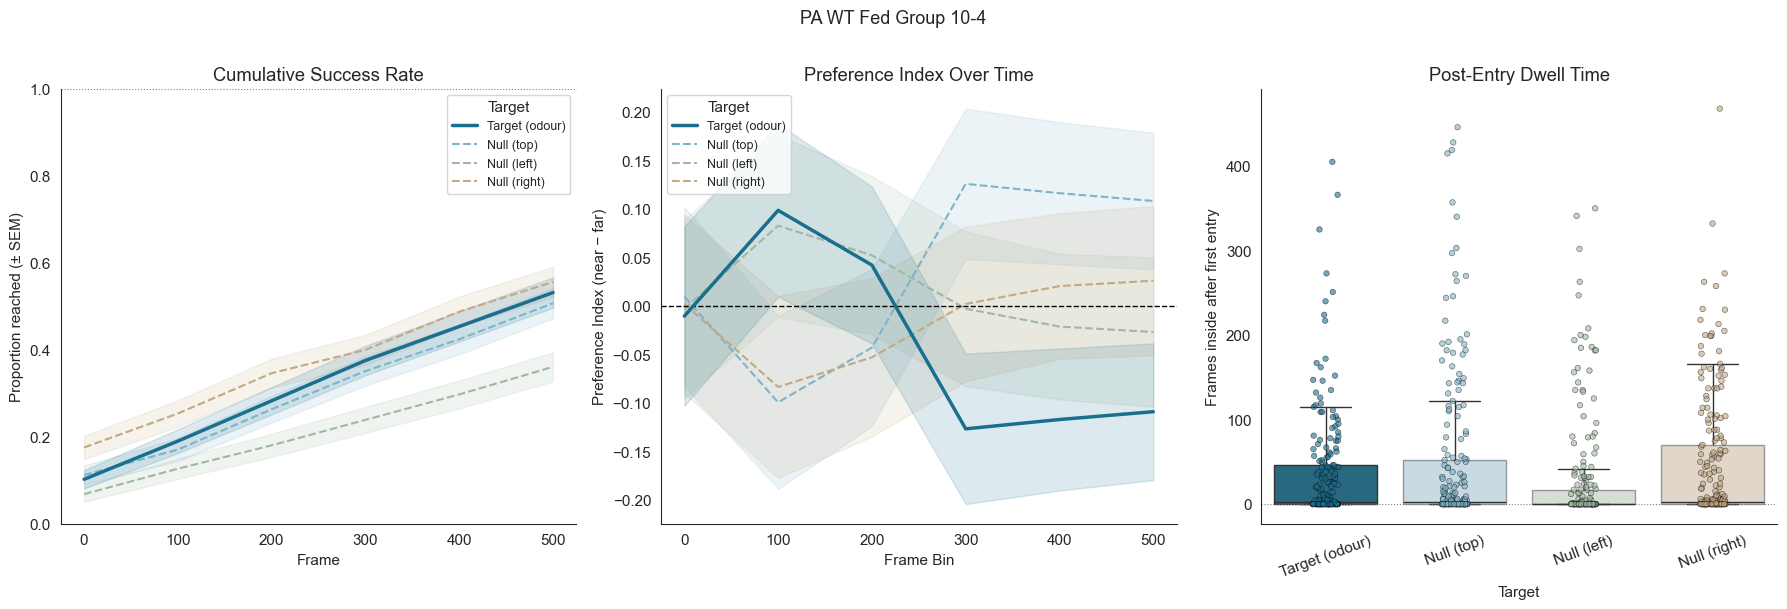

In [10]:
for condition in sorted(df['Condition'].unique()):
    _,_,_ = figures.behavior_summary_directional(df, condition)

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


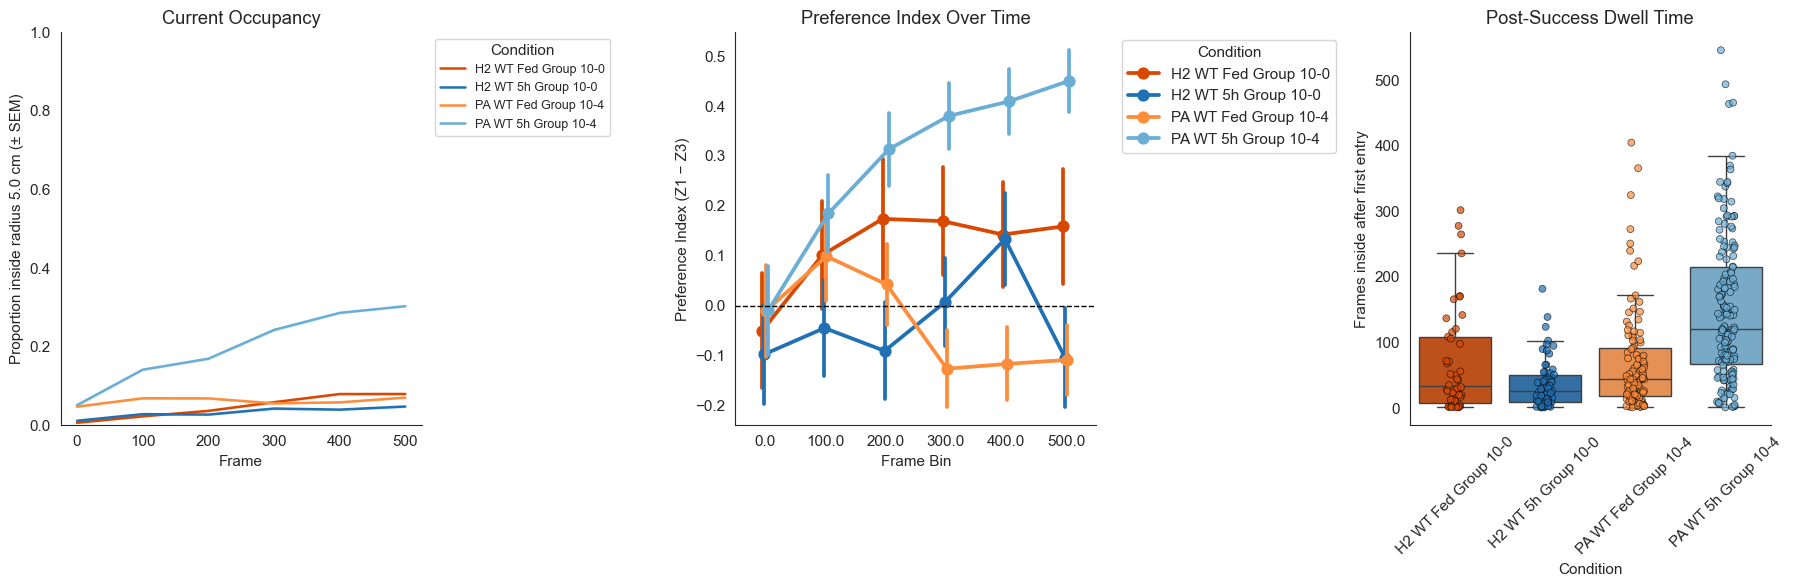

In [11]:
occupancy_df, pref_df, dwell_df = figures.behavior_summary_current_occupancy(df)

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1310: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1318: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


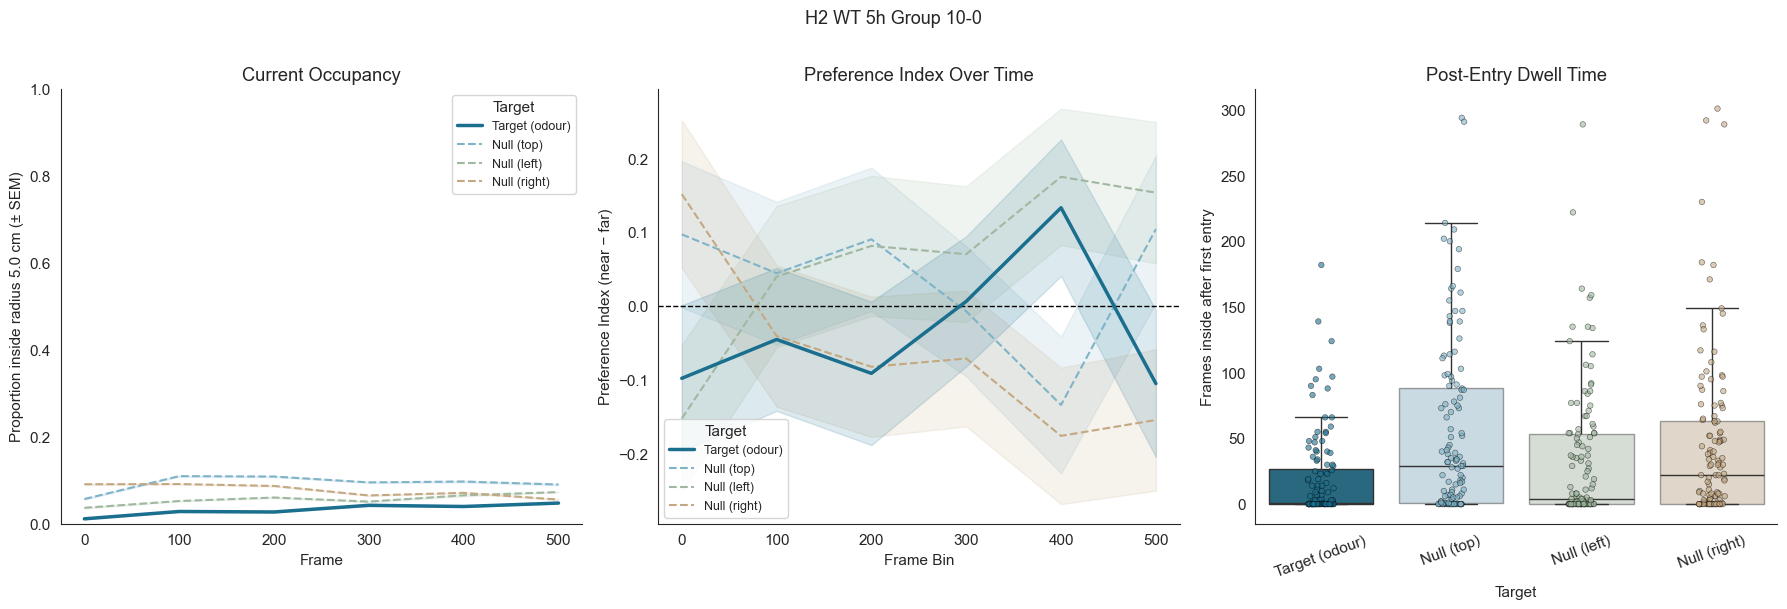

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1310: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1318: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


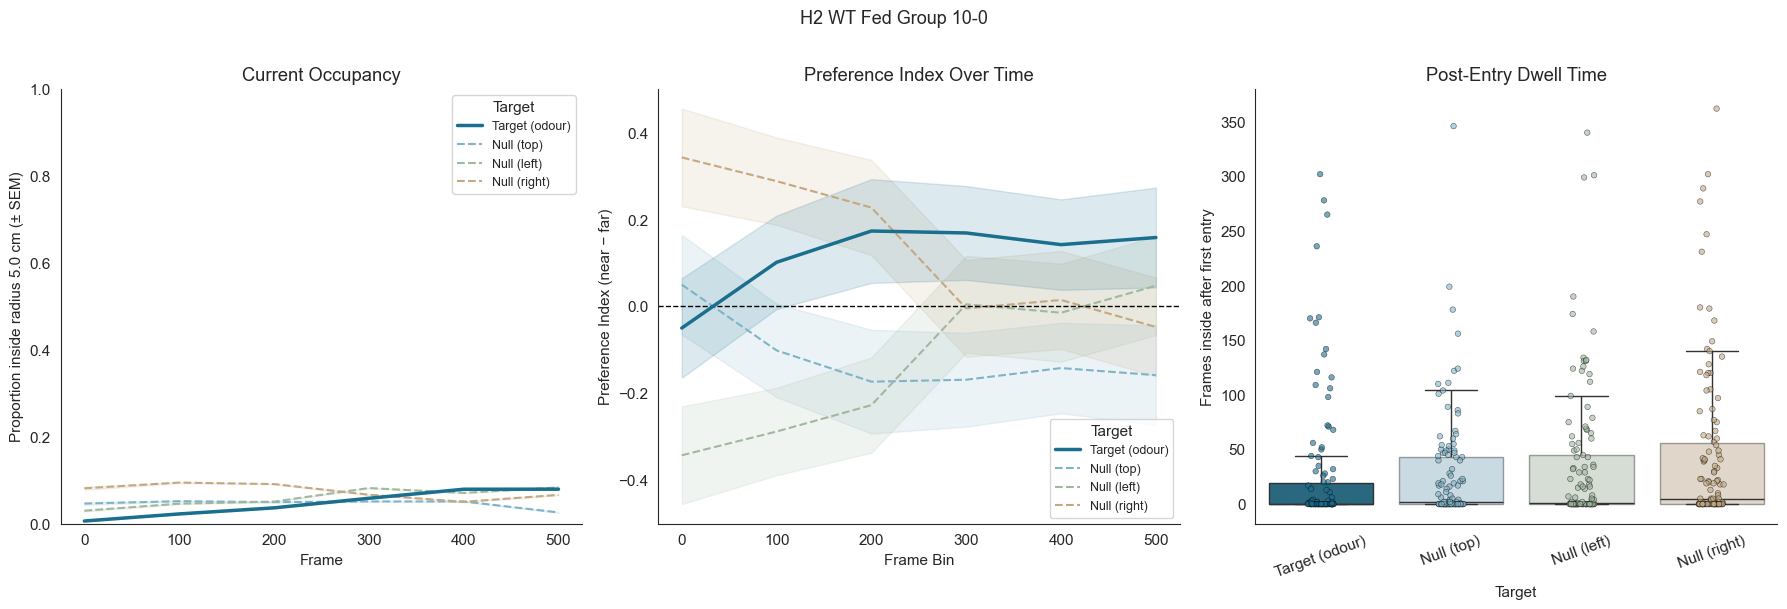

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1310: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1318: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


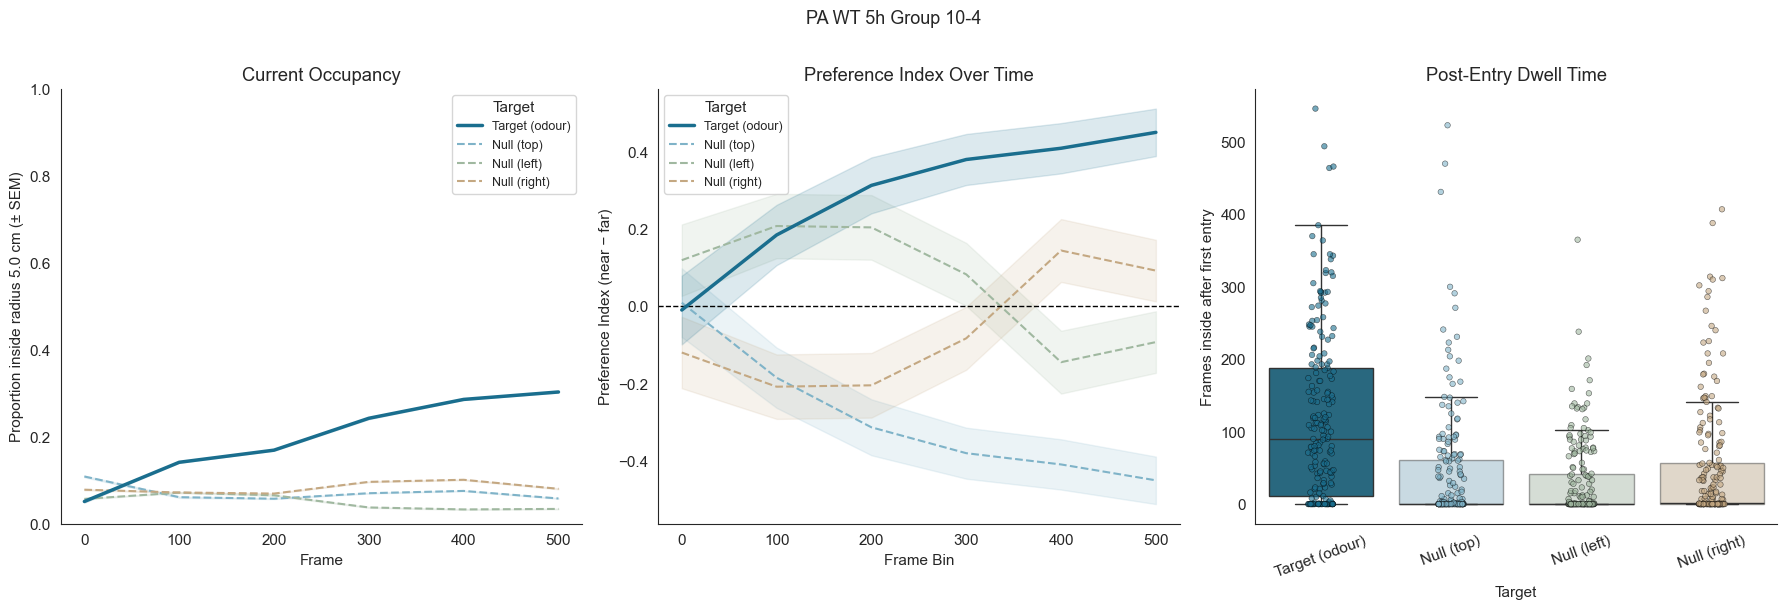

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1310: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:1318: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


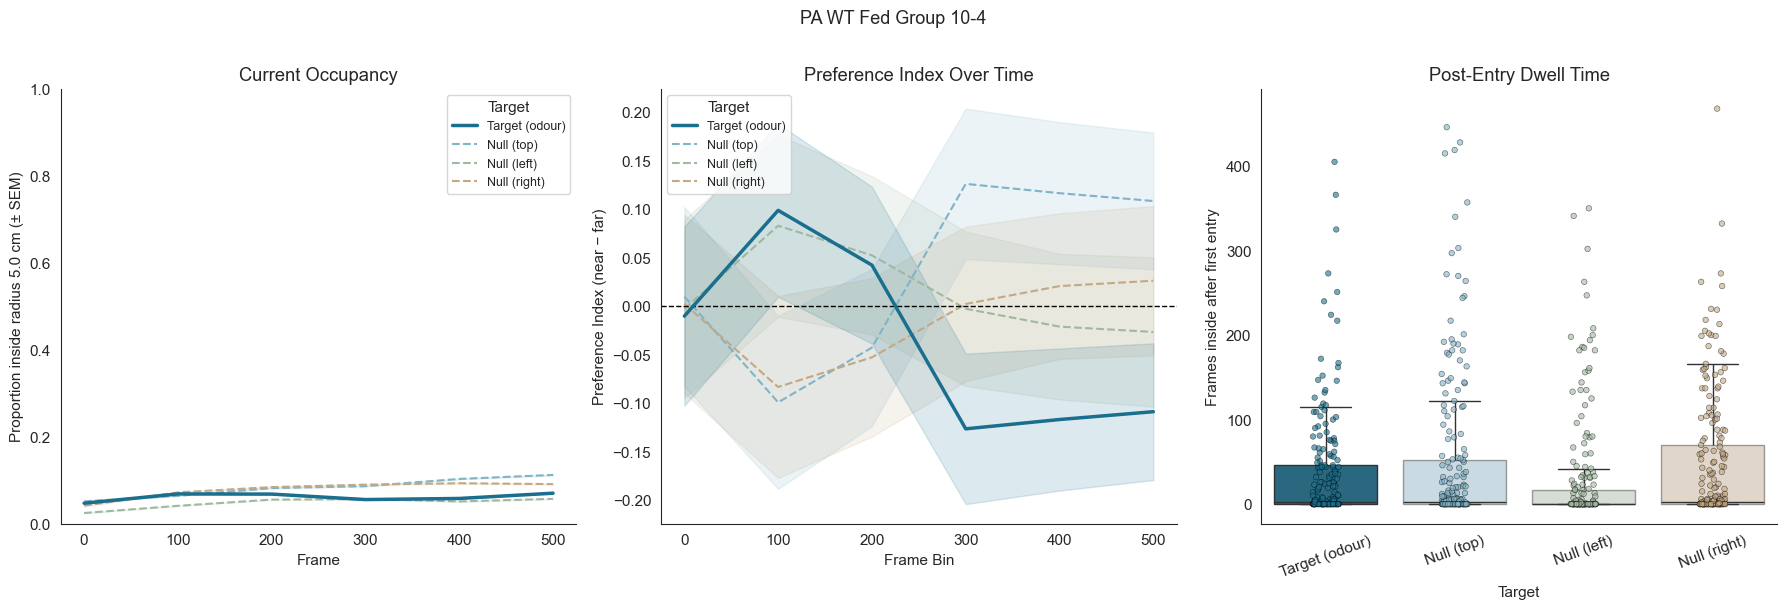

In [12]:
for condition in sorted(df['Condition'].unique()):
    _,_,_ = figures.behavior_summary_directional_occupancy(df, condition)

### 3B  Trajectory heatmaps

Spatial density heatmap for each condition, split into equal thirds of the
frame range. The colour scale is logarithmic so sparse visits are still visible.

We loop over conditions here because the function is designed to produce one
figure per condition — this keeps each heatmap readable rather than trying to
overlay all conditions in one plot.

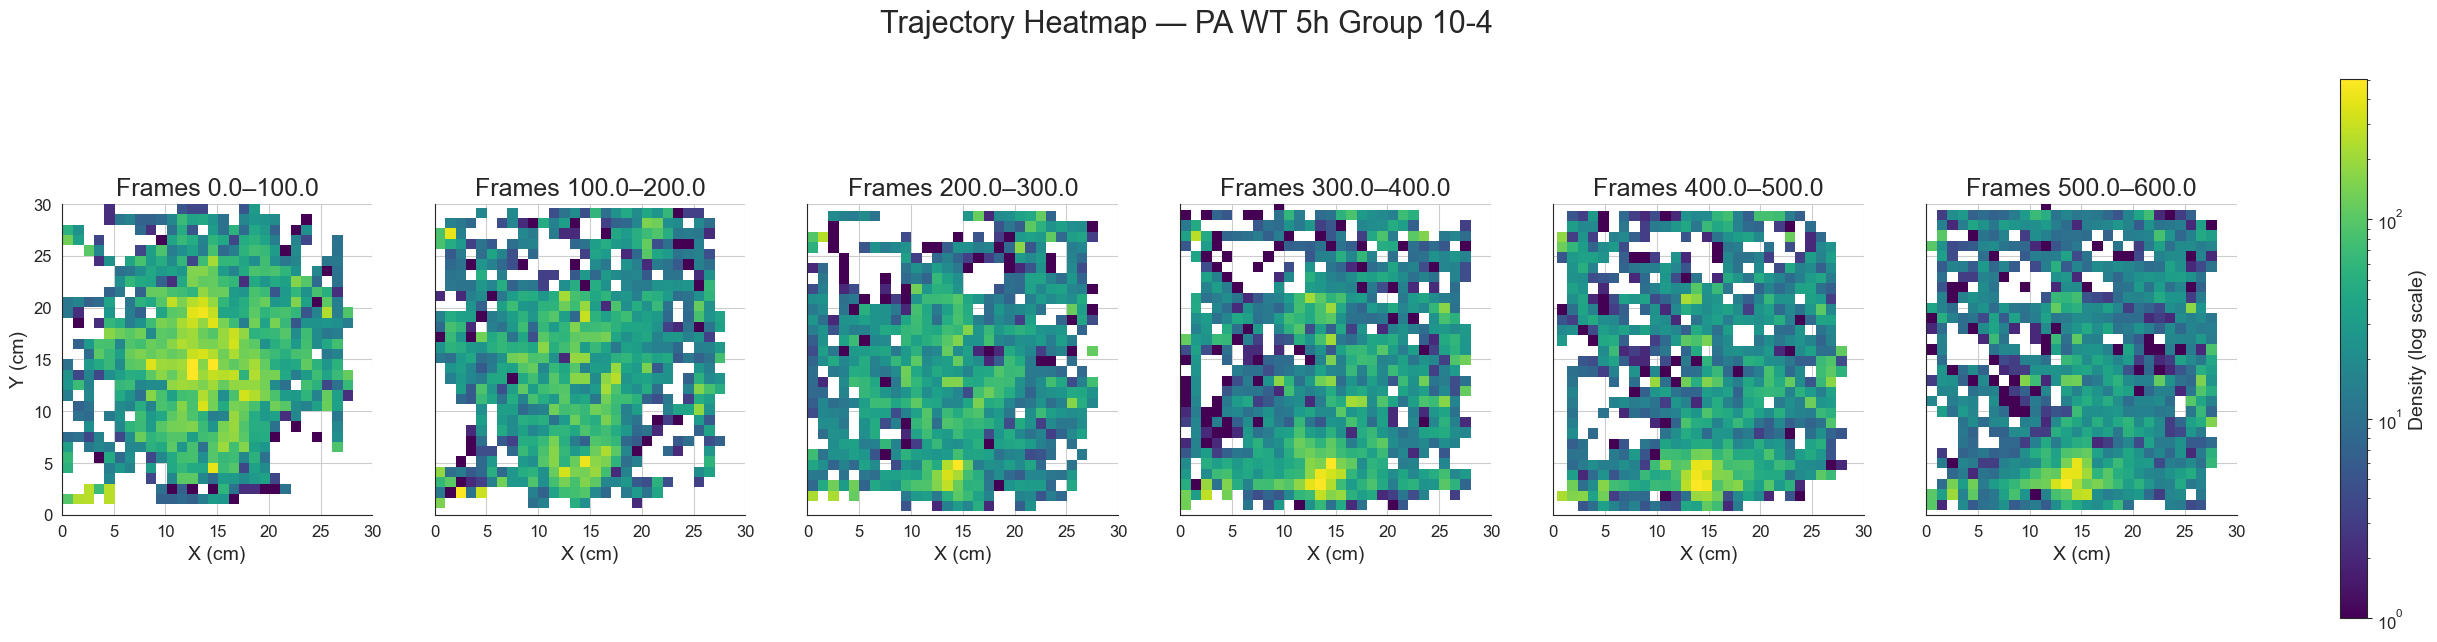

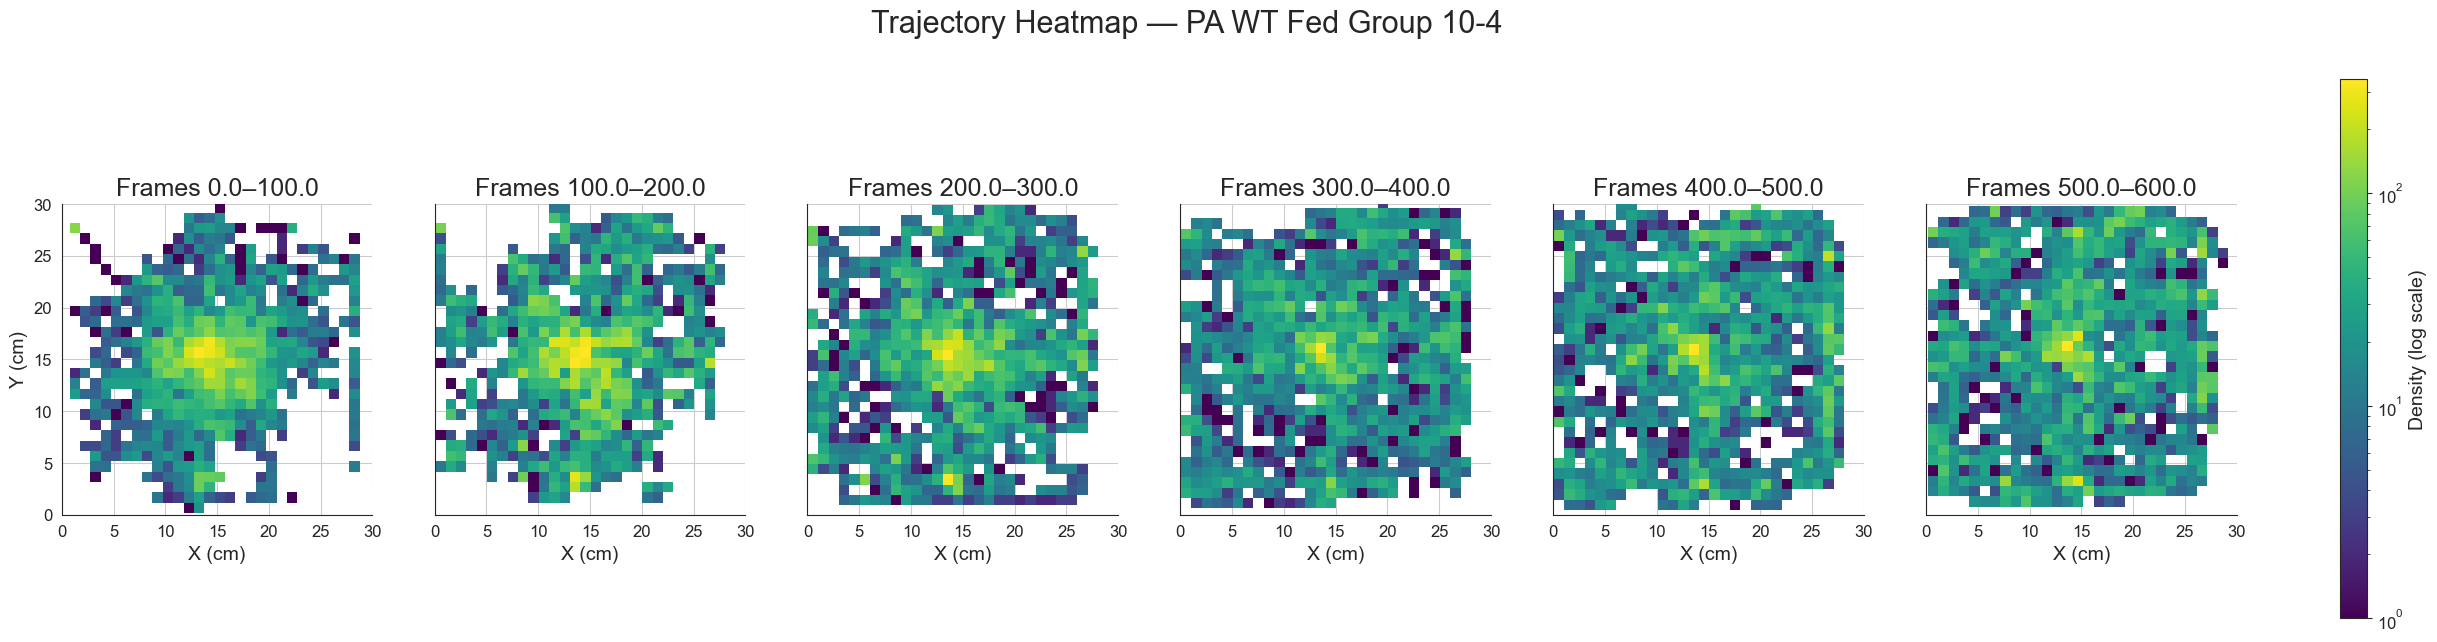

In [24]:
for condition in sorted(df_PA['Condition'].unique()):
    figures.trajectory_heatmaps(df_PA, condition=condition)

### 3C  Zone proportions

Mean proportion of time spent in Bottom / Middle / Top thirds of the arena,
shown separately for Early / Mid / Late phases of the experiment.

Each subplot column is one concentration. Each row is one time phase.
Error bars are SEM across replicates (Trial × Condition).

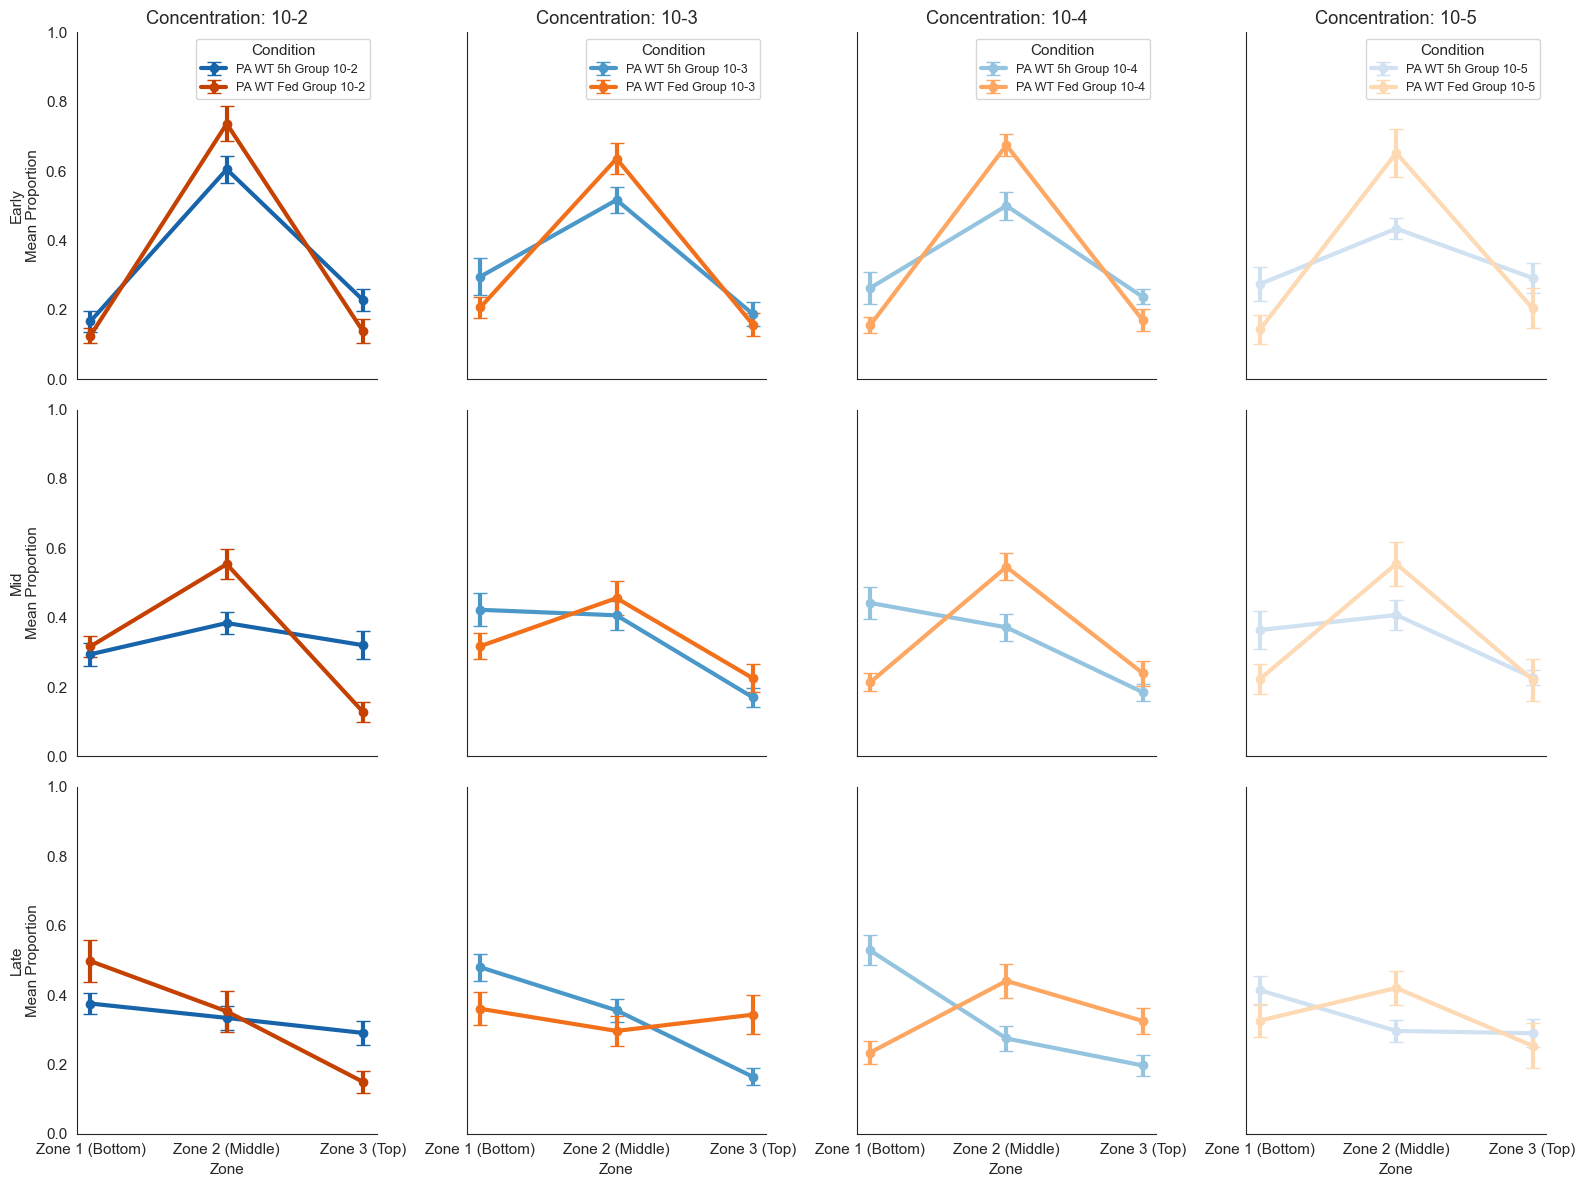

In [28]:
figures.zone_means(df_PA)

### 3D  Radial Sholl heatmaps

Polar heatmap showing where individuals concentrate around the odour source
over time. Each wedge is one frame bin; each ring is one spatial bin (default
2 cm). Colour = proportion of individuals at that radius in that time bin.

Like heatmaps, this is one figure per condition so we loop.

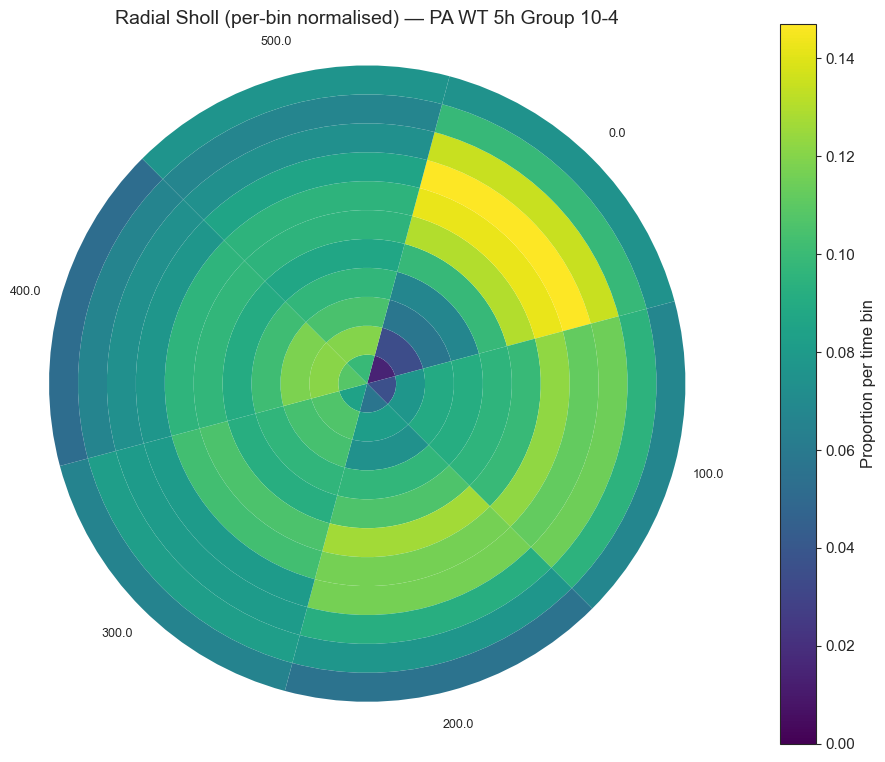

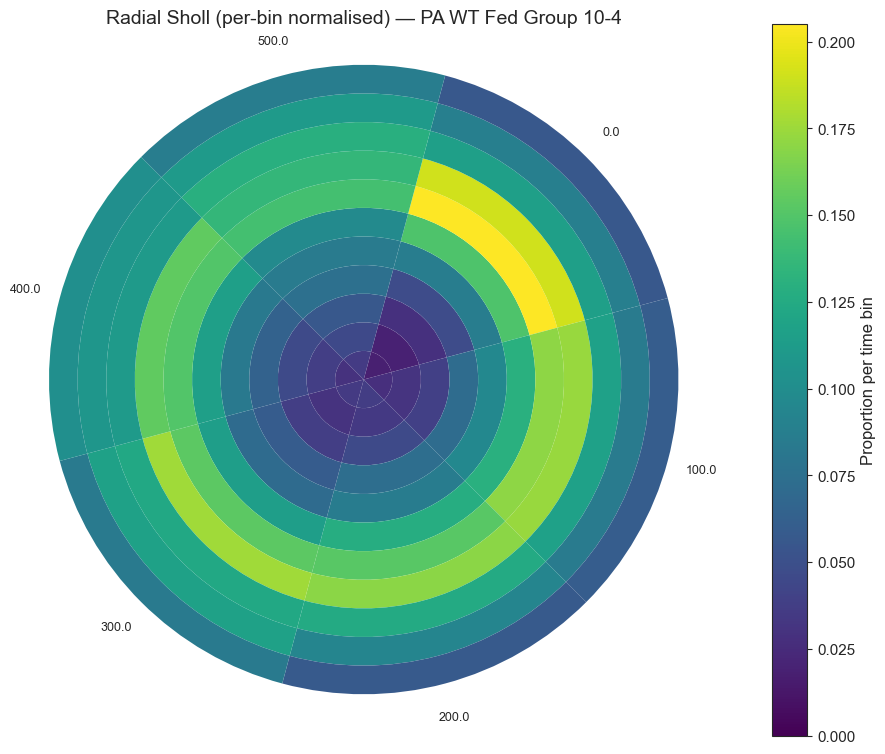

In [30]:
for condition in sorted(df_PA['Condition'].unique()):
    figures.sholl_heatmap(df_PA[df_PA['Condition'] == condition])

## 4  Extended analyses (10% of runs)

### 4A  Speed (binned)

Per-individual mean speed within 30-frame bins. Speed is filtered to the valid
range (0.5–2.0 cm/s) *inside* the function, so you pass the full `df`.

Each box = distribution of individual means for one condition in one bin.
Useful for checking whether starvation state changes locomotion speed
independently of navigation.

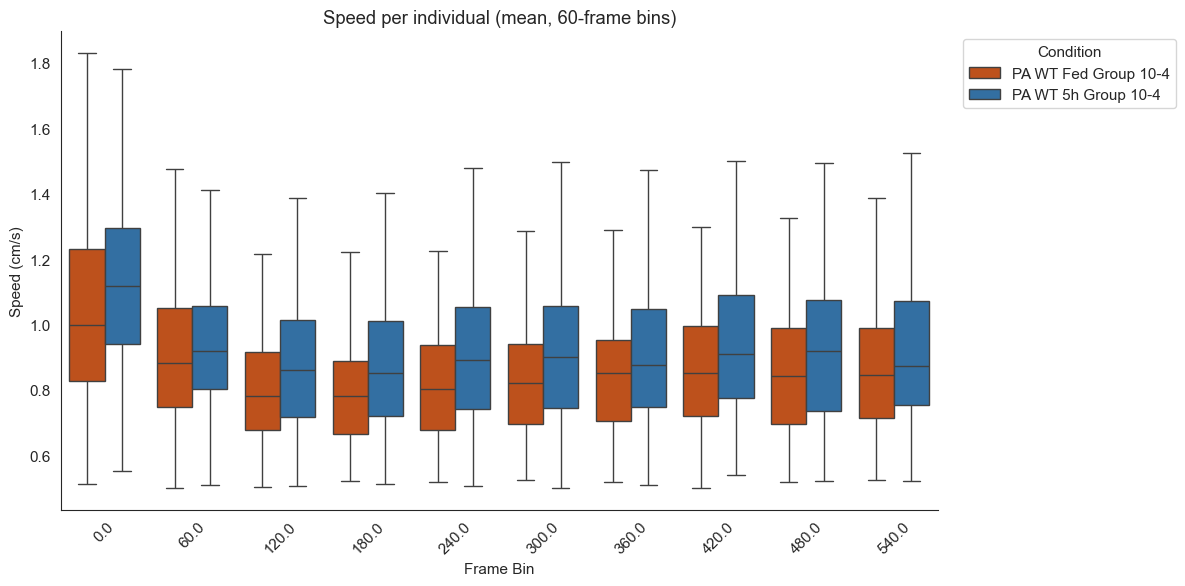

In [32]:
speed_df = figures.speed_binned_boxplot(df_PA, bin_size=60)

### 4B  Stopping frequency

Fraction of frames each individual spends below the stop threshold (default
0.2 cm/s). This must receive the **unfiltered** `df` — if you passed a
speed-filtered dataframe the stopped frames would already be gone and every
individual would show 0% stopping.

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:469: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


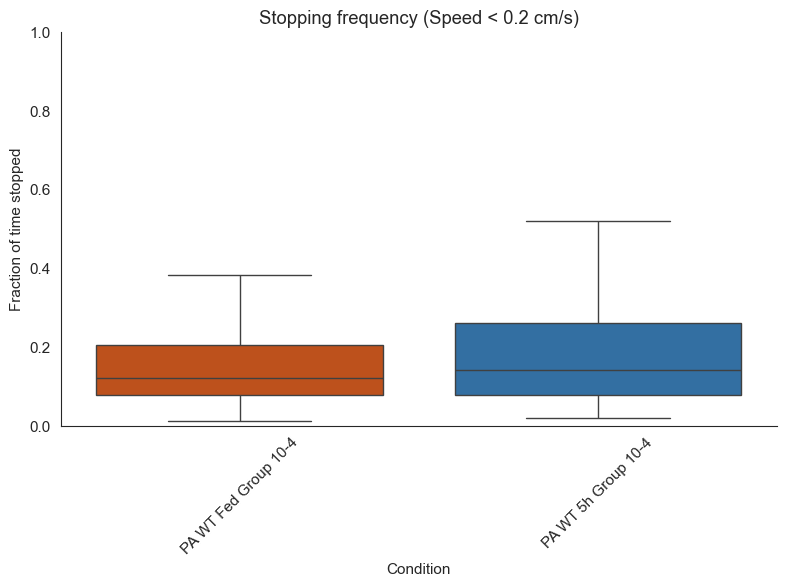

In [33]:
stop_df = figures.stopping_frequency(df_PA)   # pass df, not a filtered version

### 4C  Central fraction

Proportion of individuals within a 5 cm radius of the arena centre (15, 15)
over time. Computed as n_inside / n_total per frame before averaging into
bins, so groups of different sizes are directly comparable.

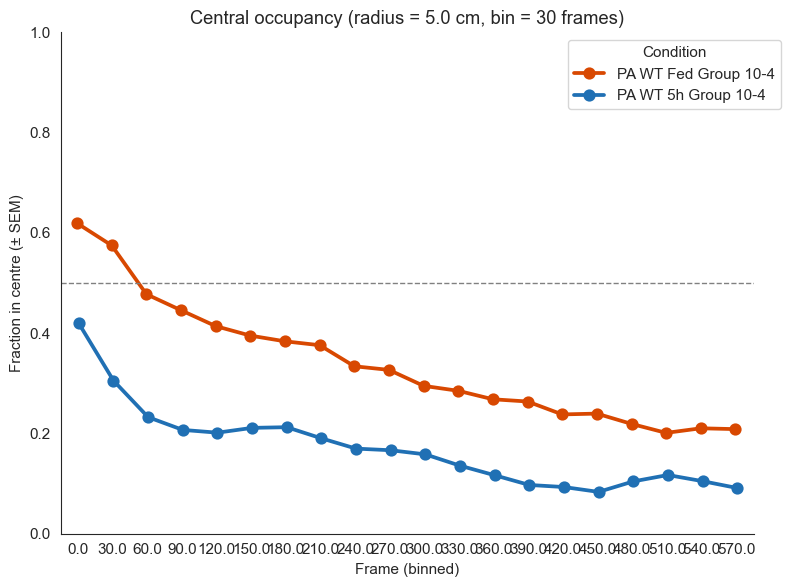

In [35]:
central_df = figures.central_fraction(df_PA)

### 4D  Logistic probability curves

For each condition, computes P(success | individual crossed radius r) across
50 radius steps from the arena edge down to the success zone.

A 4-parameter logistic is fitted to each curve, with bootstrap CI bands
(default 500 resamples, 95% CI). The inflection point `r0` estimates the
radius at which individuals commit to navigating to the target.

The function returns a dict; the comparison table is the most useful part
for reporting — it shows A, L, k, r0 as `estimate ± half-CI`.

d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:669: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_success = grp.apply(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:674: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_r  = grp.apply(
d:\Experiment Work\larva-locater Repo\larva-locater\figures.py:669: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. Thi

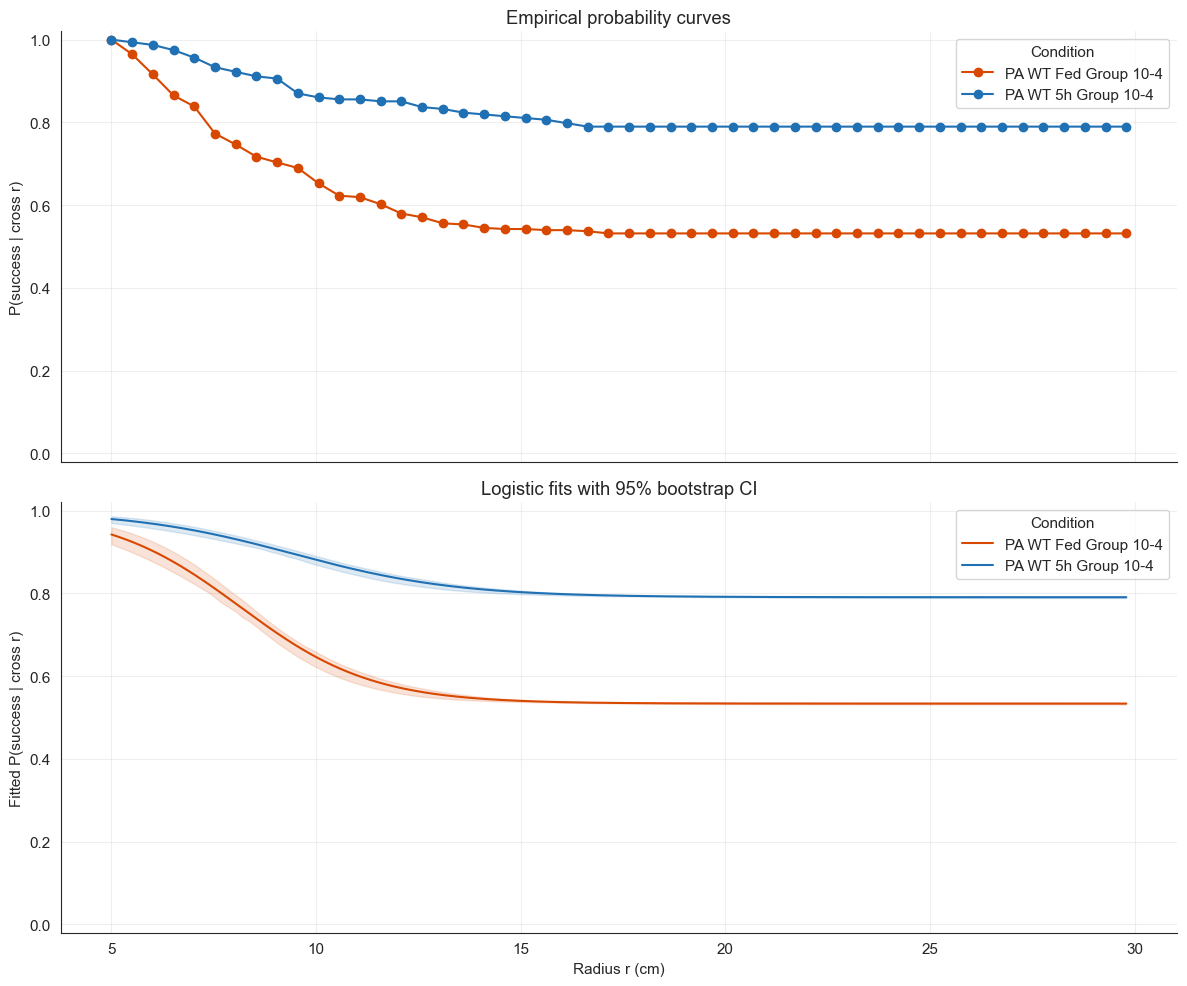

,Condition,A,L,k,r0,R2
1,PA WT 5h Group 10-4,0.791 ± 0.002,1.000 ± 0.000,0.501 ± 0.086,9.455 ± 0.325,0.982
0,PA WT Fed Group 10-4,0.534 ± 0.002,1.000 ± 0.000,0.621 ± 0.099,8.155 ± 0.275,0.987


In [36]:
logistic_results = figures.probability_logistic(df_PA)

# Print the parameter comparison table
logistic_results['comparison_table']

### 4E  Paired Fed vs 5h preference index

Compares Fed and 5h PI within a specific frame window, using per-trial means
as the statistical unit (so n = number of trials, not number of frames).

Conditions are grouped on the x-axis by their (Concentration, Genotype,
Collective) combination, with Fed and 5h side-by-side within each group.

You must supply either `frame_range=(start, end)` or `last_n_frames=int`.
The example below compares the final 100 frames.

In [ ]:
pi_trial_df = figures.preference_index_paired(
    df,
    last_n_frames=100,
    # frame_range=(400, 600),   # alternative: specific window
)

## 5  Working with the underlying data

Every `figures.*` function returns its underlying DataFrame(s).
You can call `metrics.*` directly if you want the numbers without a plot,
for example to run statistical tests.

The cells below show the pattern — uncomment and adapt as needed.

In [ ]:
# --- Get success rate per individual for stats ---
# sr = metrics.success_rate(df)
# sr.groupby('Condition')['Success'].agg(['mean', 'sem'])

# --- Get PI per frame bin per individual ---
# pi = metrics.preference_index(df)
# pi[pi['FrameBin'] == 500].groupby('Condition')['PreferenceIndex'].agg(['mean','sem'])

# --- Get dwell times for a specific condition ---
# dw = metrics.dwell_time(df)
# dw[dw['Condition'] == 'ACV Canton-S Fed Single 10-3']

## 6  Customisation reference

### Changing arena constants for one session
Pass overrides directly to the function rather than editing `config.py`:
```python
figures.behavior_summary_overtime(df, target_x=10, target_y=5, radius=3)
```

### Changing arena constants permanently
Edit `config.py` — all functions pick up the new values automatically.

### Adding display labels
If your condition names are long, pass a `display_labels` dict to any figure
function to use shorter axis labels without renaming columns in the data:
```python
labels = {
    'ACV Canton-S Fed Single 10-3': 'CS Fed 10-3',
    'ACV Canton-S 5h Single 10-3':  'CS 5h 10-3',
}
figures.behavior_summary_overtime(df, display_labels=labels)
```

### Filtering to a subset of conditions
Filter `df` before passing — the palette and ordering update automatically:
```python
df_subset = df[df['Concentration'] == '10-3']
figures.behavior_summary_overtime(df_subset)
```

### Collective behaviour (Group vs simulated Single)
The neighbour-distance analysis requires an enriched DataFrame:
```python
df_combined = larva_io.create_combined_real_simulated_df(df)
# df_combined now has AvgNeighborDist and NearestNeighborDist columns
```